In [15]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

In [16]:
# ============================================================
# During the Adaptation phase, all network weights are frozen
# and then all Dense layers are unfrozen:
#   - Dense "base" (256 units)
#   - Dense "residual" (256 units)
#   - Final Dense layer (softmax)
# Consequence: much more effective adaptation and improved
# cross-subject performance.
# ============================================================


# ======= RESNET DEFINITION ======= #

def create_resnet(input_dim, num_classes, dropout_pcg=0.25, factors=256):
    inp = Input(shape=(input_dim,))

    # First "base" block
    out = Dense(factors, activation="relu")(inp)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    # "Residual" block
    res = Dense(factors, activation="relu")(out)
    res = BatchNormalization()(res)
    res = Dropout(dropout_pcg)(res)

    # Skip connection
    out = Add()([out, res])

    # Concatenation with original input
    out = Concatenate()([out, inp])

    # Softmax output
    out = Dense(num_classes, activation="softmax")(out)

    m = Model(inp, out)
    m.compile(
        loss="categorical_crossentropy",
        optimizer=tf.keras.optimizers.RMSprop(1e-3),
        metrics=["accuracy"]
    )
    return m


# ======= SEED FOR REPRODUCIBILITY ======= #

np.random.seed(42)
tf.random.set_seed(42)


# ======= OUTPUT DIRECTORIES ======= #

base_dir = r"C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.2_all_dense_unfrozen"

results_dir = os.path.join(base_dir, "results")
os.makedirs(results_dir, exist_ok=True)

best_resnet_dir = os.path.join(base_dir, "best_model_resnet")
os.makedirs(best_resnet_dir, exist_ok=True)

merged_dir = os.path.join(base_dir, "merged_PSD_dataset")
os.makedirs(merged_dir, exist_ok=True)

log_path = os.path.join(
    results_dir,
    "RESNET_cross_subject_Adaptation_all_dense_log.txt"
)


def print_and_save(text, f):
    print(text)
    f.write(text + "\n")

In [17]:
# ======= TRAINING DATASET (15 SUBJECT) ======= #

train_files = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_1.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_2.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_3.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_4.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_5.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_6.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_7.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_8.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_9.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_10.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_11.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_12.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_13.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_14.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_15.csv'
]

# Merge the 15 subjects datasets
df_list = [pd.read_csv(file) for file in train_files]
psd_15 = pd.concat(df_list, ignore_index=True)
psd_15.to_csv(os.path.join(merged_dir, "PSD_dataset_15.csv"), index=False)

In [18]:
# ======= TRAINING SET LOADING ======= #

df = psd_15

# PSD features (all columns except Event Id)
X = df.drop("Event Id", axis=1).astype(float).values
# Labels
y = df["Event Id"].values

input_dim = X.shape[1]

# Class mapping (derived ONLY from training data)
classes = np.array(sorted(np.unique(y)))
num_classes = len(classes)
to_index = {c: i for i, c in enumerate(classes)}


# ======= TRAIN/VALIDATION SPLIT ======= #

# Only for training
Xtr, Xval, ytr, yval = train_test_split(
    X, y,
    train_size=0.8,
    shuffle=True,
    stratify=y,
    random_state=42
)


# ======= SCALER ======= #

# Fit ONLY on training set (15 subjects)
scaler = MinMaxScaler().fit(Xtr)
Xtr_s  = scaler.transform(Xtr)
Xval_s = scaler.transform(Xval)


# ======= OVERSAMPLING ======= #

# ONLY on training set to avoid Data Leakage
df_tr = pd.DataFrame(Xtr_s)
df_tr["Event Id"] = ytr

max_n = df_tr["Event Id"].value_counts().max()
dfs = []
for cls, sub in df_tr.groupby("Event Id"):
    if len(sub) < max_n:
        sub = resample(sub, replace=True, n_samples=max_n, random_state=42)
    dfs.append(sub)

df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
Xtr_bal = df_bal.drop("Event Id", axis=1).values
ytr_bal = df_bal["Event Id"].values


# ======= ONE-HOT ======= #

ytr_cat  = to_categorical([to_index[c] for c in ytr_bal], num_classes=num_classes)
yval_cat = to_categorical([to_index[c] for c in yval], num_classes=num_classes)

In [19]:
# ======= TRAINING ======= #

model = create_resnet(input_dim, num_classes)

ckpt_path_15 = os.path.join(best_resnet_dir, "best_resnet_15.weights.h5")
ckpt_15 = ModelCheckpoint(
    ckpt_path_15,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=0
)
rlr_15 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=0
)

model.fit(
    Xtr_bal, ytr_cat,
    validation_data=(Xval_s, yval_cat),
    epochs=150,
    batch_size=64,
    callbacks=[ckpt_15, rlr_15],
    verbose=0
)

# Load the best weights from training on the 15 subjects
model.load_weights(ckpt_path_15)

In [20]:
# ======= TEST DATASETS (12 NEW SUBJECTS) ======= #

test_files = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_16.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_17.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_18.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_19.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_20.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_21.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_22.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_23.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_24.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_25.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_26.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_27.csv'
]

In [21]:
# ======= MAIN LOOP ======= #

subjects_list = [] 

with open(log_path, "w", encoding="utf-8") as f:

    print_and_save("=" * 70, f)
    print_and_save("CROSS-SUBJECT ADAPTATION TEST", f)
    print_and_save("Train: Subjects 1–15 | Test: Subjects 16–27", f)
    print_and_save("Adaptation: 20% of each new subject", f)
    print_and_save("=" * 70 + "\n", f)

    acc_list = []
    f1_list = []
    prec_list = []
    rec_list = []
    

    for test_file in test_files:

        subject_name = os.path.splitext(os.path.basename(test_file))[0]
        subjects_list.append(subject_name)

        print_and_save("=" * 70, f)
        print_and_save(f"SUBJECT: {subject_name}", f)

        # Reset to base weights (15-subject training)
        model.load_weights(ckpt_path_15)

        # Load new subject dataset
        df_new_sub = pd.read_csv(test_file)

        X_new_sub = df_new_sub.drop("Event Id", axis=1).astype(float).values
        y_new_sub = df_new_sub["Event Id"].values

        # Same normalization used for training (15 subjects)
        X_new_sub_s = scaler.transform(X_new_sub)

        # Label mapping using the 15-subject classes
        mask_known = np.isin(y_new_sub, classes)
        X_new_sub_s = X_new_sub_s[mask_known]
        y_new_sub = y_new_sub[mask_known]
        y_new_sub_idx = np.array([to_index[c] for c in y_new_sub])


        # ======= SPLIT ======= #

        # 20% Adaptation, 80% Test
        X_ft, X_test, y_ft_idx, y_test_idx = train_test_split(
            X_new_sub_s, y_new_sub_idx,
            train_size=0.2,
            shuffle=True,
            stratify=y_new_sub_idx,
            random_state=42
        )

        # One-hot ONLY for fine-tuning
        y_ft_cat = to_categorical(y_ft_idx, num_classes=num_classes)


        # ======= ADAPTATION ======= #

        # Freeze all layers
        for layer in model.layers:
            layer.trainable = False

        # Unfreeze ALL Dense layers (base, residual, softmax)
        for layer in model.layers:
            if isinstance(layer, Dense):
                layer.trainable = True

        # Re-compile with a lower learning rate
        model.compile(
            loss="categorical_crossentropy",
            optimizer=tf.keras.optimizers.RMSprop(1e-4),
            metrics=["accuracy"]
        )

        ckpt_ft_path = os.path.join(
            best_resnet_dir,
            f"best_resnet_Adaptation_{subject_name}.weights.h5"
        )
        ckpt_ft = ModelCheckpoint(
            ckpt_ft_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=0
        )
        rlr_ft = ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        )

        model.fit(
            X_ft, y_ft_cat,
            validation_split=0.2,
            epochs=60,
            batch_size=64,
            callbacks=[ckpt_ft, rlr_ft],
            verbose=0
        )

        model.load_weights(ckpt_ft_path)


        # ======= TEST ======= #

        ypred = model.predict(X_test, verbose=0)
        ypred_lab = np.argmax(ypred, axis=1)

        acc = accuracy_score(y_test_idx, ypred_lab)
        f1m = f1_score(y_test_idx, ypred_lab, average="macro")
        prec = precision_score(y_test_idx, ypred_lab, average="macro", zero_division=0)
        rec = recall_score(y_test_idx, ypred_lab, average="macro", zero_division=0)

        acc_list.append(acc)
        f1_list.append(f1m)
        prec_list.append(prec)
        rec_list.append(rec)

        print_and_save(f"Test Accuracy AFTER Adaptation: {acc:.4f}", f)
        print_and_save(f"Macro-F1 AFTER Adaptation: {f1m:.4f}", f)
        print_and_save(f"Macro-Precision AFTER Adaptation: {prec:.4f}", f)
        print_and_save(f"Macro-Recall AFTER Adaptation: {rec:.4f}", f)

        print_and_save(
            classification_report(
                y_test_idx,
                ypred_lab,
                labels=np.arange(num_classes),
                target_names=[str(c) for c in classes],
                zero_division=0,
                digits=4
            ),
            f
        )
        print_and_save("", f)

    print_and_save("=" * 70, f)
    print_and_save(f"MEAN ACCURACY (12 subjects): {np.mean(acc_list):.4f}", f)
    print_and_save(f"MEAN MACRO-PRECISION (12 subjects): {np.mean(prec_list):.4f}", f)
    print_and_save(f"MEAN MACRO-RECALL (12 subjects): {np.mean(rec_list):.4f}", f)
    print_and_save(f"MEAN MACRO-F1 (12 subjects): {np.mean(f1_list):.4f}", f)
    print_and_save("=" * 70, f)

# ======= ARRAYS READY FOR PLOTS (outside the file context) ======= #
subjects  = subjects_list
precision = np.array(prec_list, dtype=float)
recall    = np.array(rec_list, dtype=float)
f1_score_ = np.array(f1_list, dtype=float)  # underscore to avoid name clash with sklearn f1_score

CROSS-SUBJECT ADAPTATION TEST
Train: Subjects 1–15 | Test: Subjects 16–27
Adaptation: 20% of each new subject

SUBJECT: PSD_EEG_Subject_16
Test Accuracy AFTER Adaptation: 0.4337
Macro-F1 AFTER Adaptation: 0.3843
Macro-Precision AFTER Adaptation: 0.4065
Macro-Recall AFTER Adaptation: 0.3743
              precision    recall  f1-score   support

         0.0     0.4818    0.5938    0.5319       512
     33024.0     0.4336    0.2737    0.3356       179
     33025.0     0.3552    0.3631    0.3591       179
     33026.0     0.3841    0.2944    0.3333       180
     33027.0     0.3780    0.3464    0.3615       179

    accuracy                         0.4337      1229
   macro avg     0.4065    0.3743    0.3843      1229
weighted avg     0.4269    0.4337    0.4243      1229


SUBJECT: PSD_EEG_Subject_17


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.4223
Macro-F1 AFTER Adaptation: 0.3529
Macro-Precision AFTER Adaptation: 0.3808
Macro-Recall AFTER Adaptation: 0.3419
              precision    recall  f1-score   support

         0.0     0.4866    0.6387    0.5524       512
     33024.0     0.4717    0.2793    0.3509       179
     33025.0     0.2420    0.2123    0.2262       179
     33026.0     0.3987    0.3389    0.3664       180
     33027.0     0.3050    0.2402    0.2687       179

    accuracy                         0.4223      1229
   macro avg     0.3808    0.3419    0.3529      1229
weighted avg     0.4095    0.4223    0.4070      1229


SUBJECT: PSD_EEG_Subject_18


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.4597
Macro-F1 AFTER Adaptation: 0.3888
Macro-Precision AFTER Adaptation: 0.4222
Macro-Recall AFTER Adaptation: 0.3787
              precision    recall  f1-score   support

         0.0     0.4901    0.6777    0.5689       512
     33024.0     0.3077    0.1788    0.2261       179
     33025.0     0.4740    0.4581    0.4659       179
     33026.0     0.4779    0.3611    0.4114       180
     33027.0     0.3611    0.2179    0.2718       179

    accuracy                         0.4597      1229
   macro avg     0.4222    0.3787    0.3888      1229
weighted avg     0.4406    0.4597    0.4376      1229


SUBJECT: PSD_EEG_Subject_19


...

Test Accuracy AFTER Adaptation: 0.5045
Macro-F1 AFTER Adaptation: 0.4568
Macro-Precision AFTER Adaptation: 0.4863
Macro-Recall AFTER Adaptation: 0.4429
              precision    recall  f1-score   support

         0.0     0.5213    0.6699    0.5863       512
     33024.0     0.3386    0.2402    0.2810       179
     33025.0     0.5170    0.4246    0.4663       179
     33026.0     0.5506    0.5444    0.5475       180
     33027.0     0.5042    0.3352    0.4027       179

    accuracy                         0.5045      1229
   macro avg     0.4863    0.4429    0.4568      1229
weighted avg     0.4958    0.5045    0.4919      1229


SUBJECT: PSD_EEG_Subject_26


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.4093
Macro-F1 AFTER Adaptation: 0.3506
Macro-Precision AFTER Adaptation: 0.3759
Macro-Recall AFTER Adaptation: 0.3437
              precision    recall  f1-score   support

         0.0     0.4594    0.5859    0.5150       512
     33024.0     0.3854    0.2067    0.2691       179
     33025.0     0.3719    0.4134    0.3915       179
     33026.0     0.2733    0.2278    0.2485       180
     33027.0     0.3893    0.2849    0.3290       179

    accuracy                         0.4093      1229
   macro avg     0.3759    0.3437    0.3506      1229
weighted avg     0.3984    0.4093    0.3951      1229


SUBJECT: PSD_EEG_Subject_27


C:\Users\franc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Test Accuracy AFTER Adaptation: 0.4825
Macro-F1 AFTER Adaptation: 0.4373
Macro-Precision AFTER Adaptation: 0.4617
Macro-Recall AFTER Adaptation: 0.4238
              precision    recall  f1-score   support

         0.0     0.5101    0.6406    0.5680       512
     33024.0     0.3821    0.2626    0.3113       179
     33025.0     0.4398    0.4078    0.4232       179
     33026.0     0.4698    0.3889    0.4255       180
     33027.0     0.5068    0.4190    0.4587       179

    accuracy                         0.4825      1229
   macro avg     0.4617    0.4238    0.4373      1229
weighted avg     0.4748    0.4825    0.4727      1229


MEAN ACCURACY (12 subjects): 0.4700
MEAN MACRO-PRECISION (12 subjects): 0.4445
MEAN MACRO-RECALL (12 subjects): 0.3973
MEAN MACRO-F1 (12 subjects): 0.4104


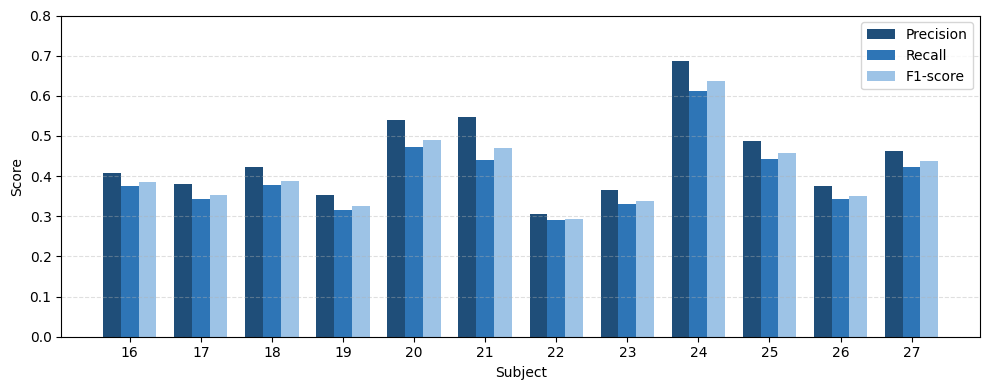

Saved plot: C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.2_all_dense_unfrozen\results\prf_per_subject_blue.png


In [24]:
# ======= PLOT 1: Subjects on X, metrics on Y ======= #
import matplotlib.pyplot as plt
# X axis: subjects numbered from 1 to N
x = np.arange(len(subjects))
x_labels = np.arange(16, 16+len(subjects))

width = 0.25

plt.figure(figsize=(10, 4))

plt.bar(
    x - width,
    precision,
    width,
    label="Precision",
    color="#1f4e79"   # dark blue
)

plt.bar(
    x,
    recall,
    width,
    label="Recall",
    color="#2e75b6"   # medium blue
)

plt.bar(
    x + width,
    f1_score_,
    width,
    label="F1-score",
    color="#9dc3e6"   # light blue
)

plt.xticks(x, x_labels)
plt.ylim(0, 0.8)
plt.ylabel("Score")
plt.xlabel("Subject")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save at high resolution for paper
plot_path = os.path.join(results_dir, "prf_per_subject_blue.png")
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"Saved plot: {plot_path}")


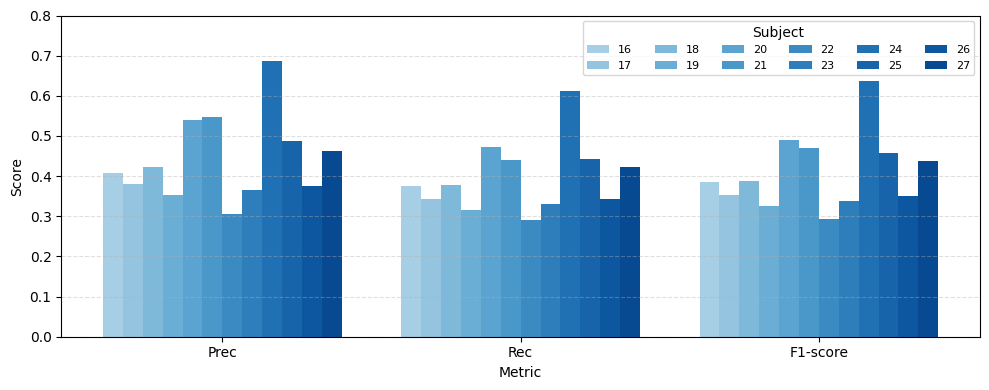

Saved plot: C:\Users\franc\Desktop\GitHub\05-Test_4_Cross_Subject_Adaptation\4.2_all_dense_unfrozen\results\prf_grouped_by_metric_blue.png


In [28]:
# ======= PLOT 2: Metrics on X, bars are subjects (blue scale, numeric subjects, save 330dpi) ======= #

import matplotlib.cm as cm
import matplotlib

metrics = ["Prec", "Rec", "F1-score"]
x = np.arange(len(metrics))

n_subj = len(subjects)

# Subject labels: 16–27
subj_labels = [str(i) for i in range(16, 16 + n_subj)]

bar_w = min(0.08, 0.8 / n_subj)  # width adaptable to number of subjects

# Blue shades (avoid too-light tones)
cmap = matplotlib.colormaps.get_cmap("Blues")
colors = [cmap(v) for v in np.linspace(0.35, 0.90, n_subj)]

plt.figure(figsize=(10, 4))

for i in range(n_subj):
    values = [precision[i], recall[i], f1_score_[i]]
    offset = (i - (n_subj - 1) / 2) * bar_w
    plt.bar(
        x + offset,
        values,
        bar_w,
        label=subj_labels[i],
        color=colors[i]
    )

plt.xticks(x, metrics)
plt.ylim(0, 0.8)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.legend(title="Subject", ncol=6, fontsize=8)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plot_path = os.path.join(results_dir, "prf_grouped_by_metric_blue.png")
plt.savefig(plot_path, dpi=330)
plt.show()

print(f"Saved plot: {plot_path}")
